In [1]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [2]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

In [3]:
train_input = train_input.reshape(-1,1)
test_input = test_input.reshape(-1,1)

In [4]:
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)
print(knr.predict([[50]]))


[1033.33333333]


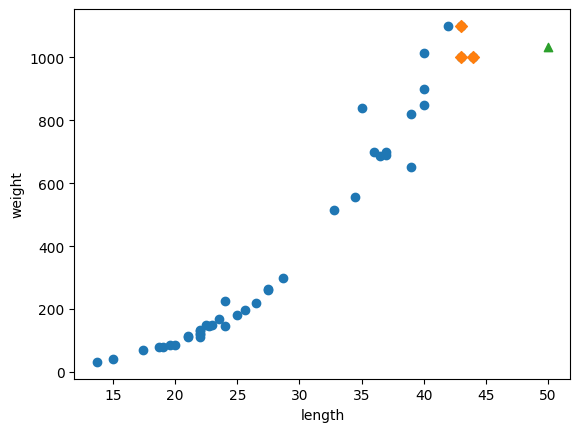

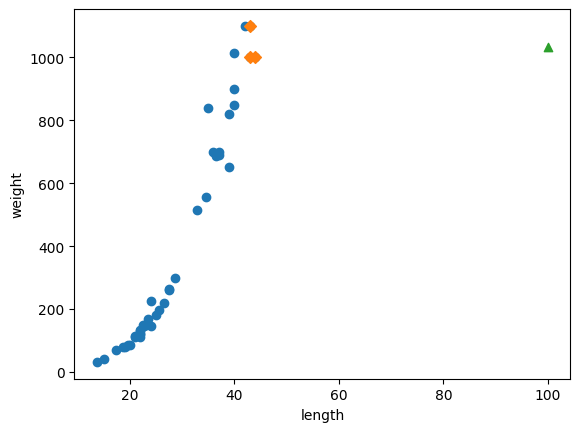

In [5]:
import matplotlib.pyplot as plt

# 50cm 농어의 이웃 구하기
distance, indexes = knr.kneighbors([[50]])
plt.scatter(train_input, train_target)                # 훈련세트 산포도 그리기
plt.scatter(train_input[indexes], train_target[indexes], marker='D')  # 훈련세트 중 이웃 샘플
plt.scatter(50, knr.predict([[50]]), marker='^')      # 50cm 농어 무게 예측
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

# 100cm 농어의 이웃 구하기
distance, indexes = knr.kneighbors([[100]])
plt.scatter(train_input, train_target)                # 훈련세트 산포도 그리기
plt.scatter(train_input[indexes], train_target[indexes], marker='D')  # 훈련세트 중 이웃 샘플
plt.scatter(100, knr.predict([[100]]), marker='^')    # 100cm 농어 무게 예측
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

print(lr.predict([[50]]))
print(lr.predict([[100]]))


[1241.83860323]
[3192.69585141]


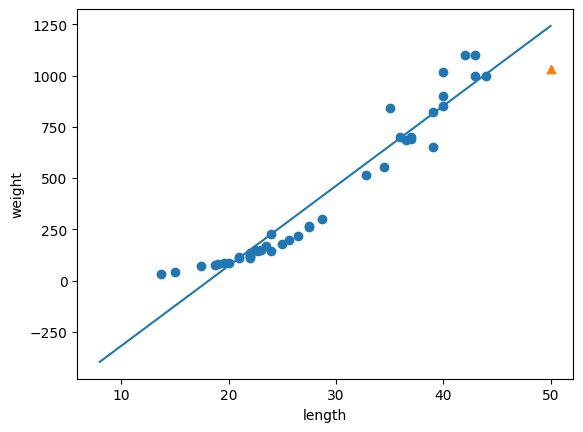

In [7]:
plt.scatter(train_input, train_target)

# 모델 파라미터에 의한 1차 방정식 그래프 그리기
plt.plot([8, 50],
         [8 * lr.coef_ + lr.intercept_,
          50 * lr.coef_ + lr.intercept_])

# 50cm 농어 무게 예측
plt.scatter(50, knr.predict([[50]]), marker='^')

plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [8]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.939846333997604
0.8247503123313558
